In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras import Model, Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_curve, auc, roc_curve
from tensorflow.keras.layers import GaussianNoise

# Q1. Sourcing the Dataset

In [ ]:
# Loading the dataset (on Google Colab)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ACML Group Project/fraudTrain.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
dftest = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ACML Group Project/fraudTest.csv')

# Q2. Data Exploration and Visualtion

In [ ]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

The data shows no missing values

In [ ]:
# Check how amount is distributed

df['amt'].describe()

,amt
count,1.296675e+06
mean,7.035104e+01
std,1.603160e+02
min,1.000000e+00
25%,9.650000e+00
50%,4.752000e+01
75%,8.314000e+01
max,2.894890e+04


In [ ]:
# Total # of fraudulent transactions

df.is_fraud.value_counts()

,count
is_fraud,
0,1289169
1,7506


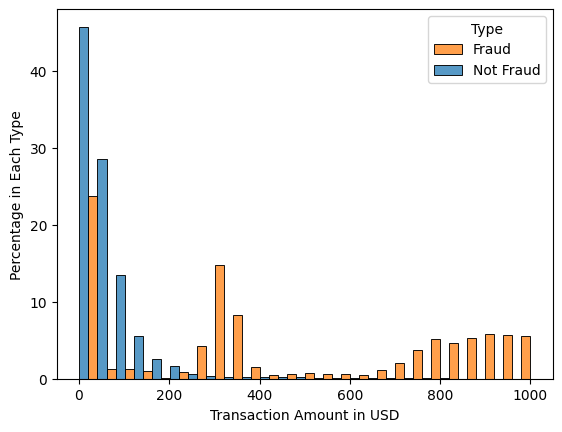

In [ ]:
# Amount vs fraud

ax=sns.histplot(x='amt',data=df[df.amt<=1000],hue='is_fraud',stat='percent',multiple='dodge',common_norm=False,bins=25)
ax.set_ylabel('Percentage in Each Type')
ax.set_xlabel('Transaction Amount in USD')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

The result is very interesting!
* Normal transactions tend to be around USD 200 or less
* Fraudulent transactions peak around USD 300 and then at the USD 800-1000 range. There are also a lot of small dollar value fradulent transactions

Text(0.5, 1.0, 'The Percentage Difference of Fraudulent over Non-Fraudulent Transations in Each Spending Category ')

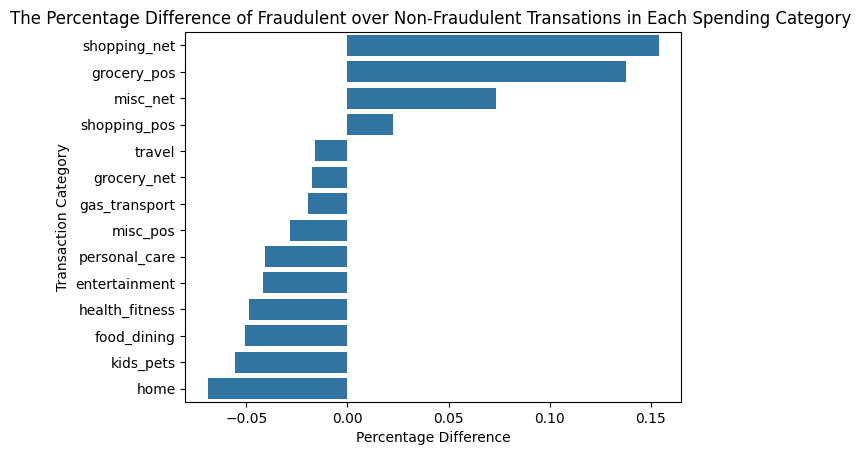

In [ ]:
# Spending category vs fraud

#calculate the percentage difference
a=df[df['is_fraud']==0]['category'].value_counts(normalize=True).to_frame().reset_index()
a.columns=['category','not fraud percentage']

b=df[df['is_fraud']==1]['category'].value_counts(normalize=True).to_frame().reset_index()
b.columns=['category','fraud percentage']
ab=a.merge(b,on='category')
ab['diff']=ab['fraud percentage']-ab['not fraud percentage']

ax=sns.barplot(y='category',x='diff',data=ab.sort_values('diff',ascending=False))
ax.set_xlabel('Percentage Difference')
ax.set_ylabel('Transaction Category')
plt.title('The Percentage Difference of Fraudulent over Non-Fraudulent Transations in Each Spending Category ')

Some spending categories see more fraud than others! Fraud tends to happen more often in 'Shopping_net', 'Grocery_pos', and 'Misc_net'

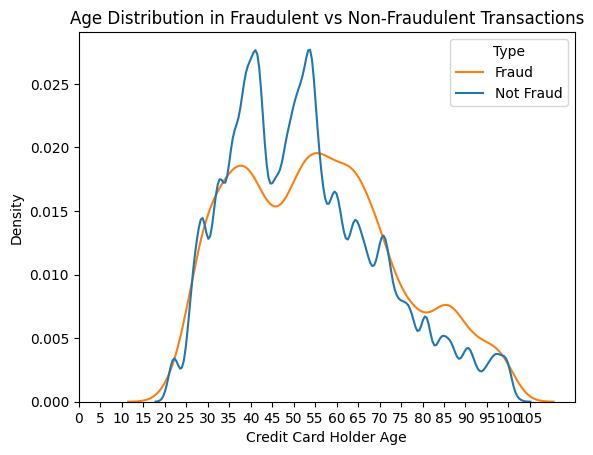

In [ ]:
# Has age got anything to do with it?

import datetime as dt
df['age']=dt.date.today().year-pd.to_datetime(df['dob']).dt.year
dftest['age']=dt.date.today().year-pd.to_datetime(dftest['dob']).dt.year

ax=sns.kdeplot(x='age',data=df, hue='is_fraud', common_norm=False)
ax.set_xlabel('Credit Card Holder Age')
ax.set_ylabel('Density')
plt.xticks(np.arange(0,110,5))
plt.title('Age Distribution in Fraudulent vs Non-Fraudulent Transactions')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

The age distribution is visibly different between 2 transaction types. In normal transactions, there are 2 peaks at the age of 37-38 and 49-50, while in fraudulent transactions, the age distribution is a little smoother and the second peak does include a wider age group from 50-65. This does suggest that older people are potentially more prone to fraud.

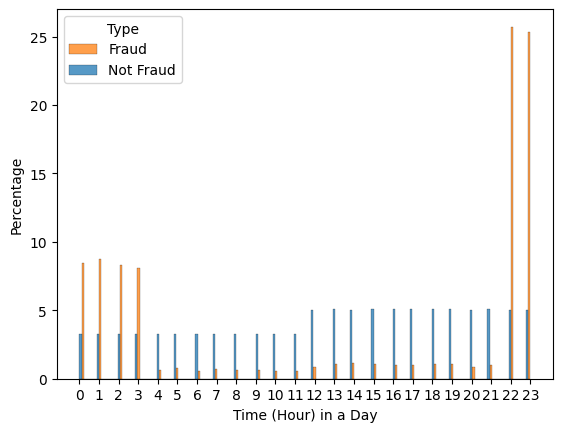

In [ ]:
# Time in the day vs Fraud

df['hour']=pd.to_datetime(df['trans_date_trans_time']).dt.hour
dftest['hour']=pd.to_datetime(dftest['trans_date_trans_time']).dt.hour

ax=sns.histplot(data=df, x="hour", hue="is_fraud", common_norm=False,stat='percent',multiple='dodge')
ax.set_ylabel('Percentage')
ax.set_xlabel('Time (Hour) in a Day')
plt.xticks(np.arange(0,24,1))
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

Fraudulent payments happen disproportionately around midnight when most people are asleep.

/tmp/ipykernel_8963/2196492473.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['',"Mon","Tue","Wed","Thu","Fri","Sat","Sun"])


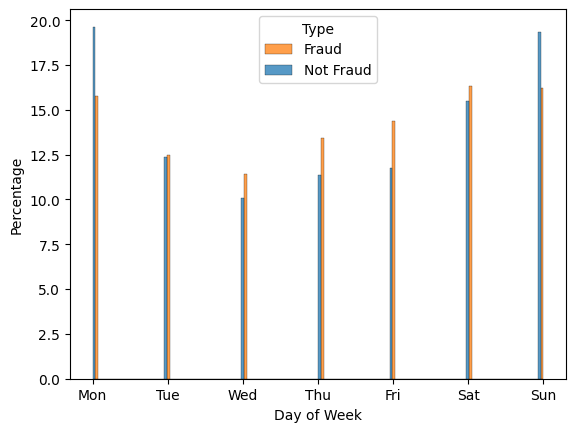

In [ ]:
# Day of week vs Fraud

df['day']=pd.to_datetime(df['trans_date_trans_time']).dt.dayofweek
dftest['day']=pd.to_datetime(dftest['trans_date_trans_time']).dt.dayofweek

ax=sns.histplot(data=df, x="day", hue="is_fraud", common_norm=False,stat='percent',multiple='dodge')
ax.set_xticklabels(['',"Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_ylabel('Percentage')
ax.set_xlabel('Day of Week')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

Fraudulent transactions tend to happen throughout the week

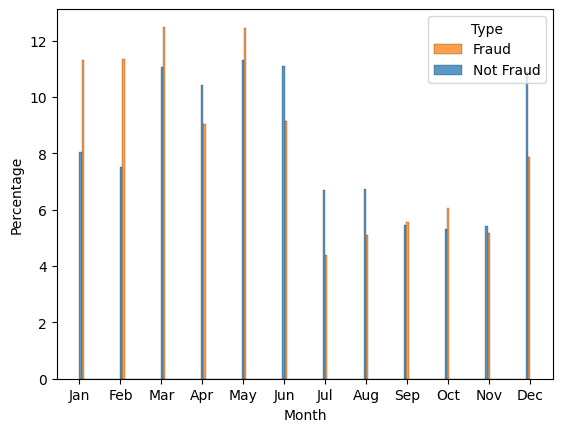

In [ ]:
# Month vs Fraud

df['month']=pd.to_datetime(df['trans_date_trans_time']).dt.month
dftest['month']=pd.to_datetime(dftest['trans_date_trans_time']).dt.month

ax=sns.histplot(data=df, x="month", hue="is_fraud", common_norm=False,stat='percent',multiple='dodge')
ax.set_ylabel('Percentage')
ax.set_xlabel('Month')
plt.xticks(np.arange(1,13,1))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul",'Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

Fraudulent transactions are crowded between Jan and June

<Axes: >

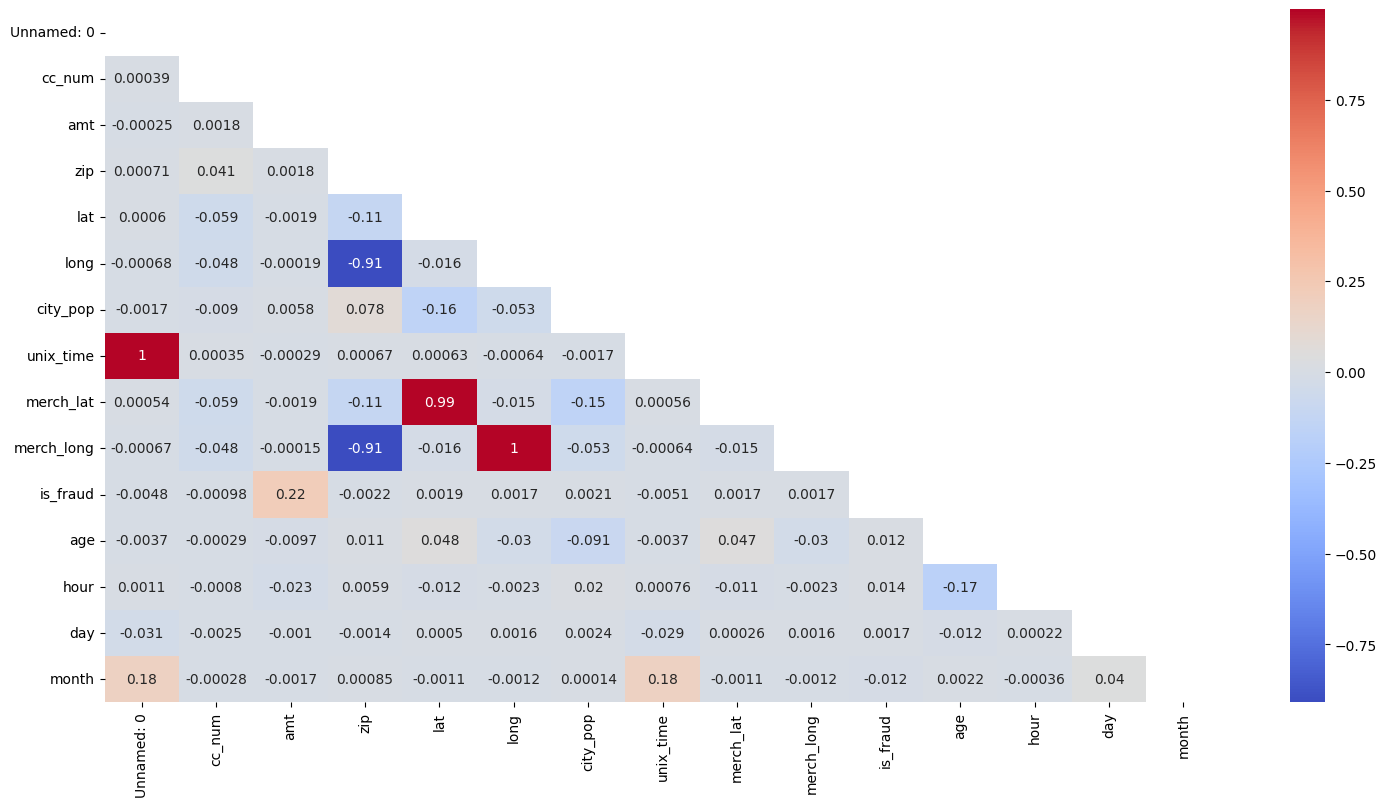

In [ ]:
# Correlation Matrix

%matplotlib inline
fig = plt.figure(figsize=(18,9))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
mask = np.triu(np.ones_like(numeric_df.corr()))
sns.heatmap(numeric_df.corr(), mask=mask, cmap='coolwarm', annot=True)

# Q3. Preprocessing

In [ ]:
# Remove all Personally Identifiable Information (PII)

df = df.drop(columns=['Unnamed: 0','cc_num','first','last','trans_num','street', 'city','state','zip', 'dob'])
dftest = dftest.drop(columns=['Unnamed: 0','cc_num','first','last','trans_num','street', 'city','state','zip', 'dob'])
df

,trans_date_trans_time,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,age,hour,day,month
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1325376018,36.011293,-82.048315,0,38,0,1,1
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1325376044,49.159047,-118.186462,0,48,0,1,1
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1325376051,43.150704,-112.154481,0,64,0,1,1
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1325376076,47.034331,-112.561071,0,59,0,1,1
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1325376186,38.674999,-78.632459,0,40,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,fraud_Reichel Inc,entertainment,15.56,M,37.7175,-112.4777,258,Geoscientist,1371816728,36.841266,-111.690765,0,65,12,6,6
1296671,2020-06-21 12:12:19,fraud_Abernathy and Sons,food_dining,51.70,M,39.2667,-77.5101,100,"Production assistant, television",1371816739,38.906881,-78.246528,0,47,12,6,6
1296672,2020-06-21 12:12:32,fraud_Stiedemann Ltd,food_dining,105.93,M,32.9396,-105.8189,899,Naval architect,1371816752,33.619513,-105.130529,0,59,12,6,6
1296673,2020-06-21 12:13:36,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,43.3526,-102.5411,1126,Volunteer coordinator,1371816816,42.788940,-103.241160,0,46,12,6,6


All columns with raw PII data are dropped.

---



In [ ]:
df.duplicated().sum()

np.int64(0)

The dataset shows zero duplicate entries.

In [ ]:
# Dropping original column

df = df.drop(columns= ['trans_date_trans_time'])

dftest = dftest.drop(columns= ['trans_date_trans_time'])

df

,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,age,hour,day,month
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,"Psychologist, counselling",1325376018,36.011293,-82.048315,0,38,0,1,1
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1325376044,49.159047,-118.186462,0,48,0,1,1
2,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1325376051,43.150704,-112.154481,0,64,0,1,1
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,Patent attorney,1325376076,47.034331,-112.561071,0,59,0,1,1
4,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,Dance movement psychotherapist,1325376186,38.674999,-78.632459,0,40,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,37.7175,-112.4777,258,Geoscientist,1371816728,36.841266,-111.690765,0,65,12,6,6
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,39.2667,-77.5101,100,"Production assistant, television",1371816739,38.906881,-78.246528,0,47,12,6,6
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,32.9396,-105.8189,899,Naval architect,1371816752,33.619513,-105.130529,0,59,12,6,6
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,43.3526,-102.5411,1126,Volunteer coordinator,1371816816,42.788940,-103.241160,0,46,12,6,6


### Distance calculation
The dataset provides us with locations in terms of coordinates. In order to calculate the distance, we use the Haversine function to find the distance between the merchants and the location of the transactions





In [ ]:
# Distance calculation when given coordinates

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dist_lat = lat2 - lat1
    dist_lon = lon2 - lon1

    a = np.sin(dist_lat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dist_lon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [ ]:
df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

dftest['distance_km'] = haversine(dftest['lat'], dftest['long'], dftest['merch_lat'], dftest['merch_long'])

df['distance_km'].head()


,distance_km
0,78.597568
1,30.212176
2,108.206083
3,95.673231
4,77.556744


In [ ]:
# Dropping original columns

df = df.drop(columns=['lat','long','merch_lat','merch_long'])

dftest = dftest.drop(columns=['lat','long','merch_lat','merch_long'])

df

,merchant,category,amt,gender,city_pop,job,unix_time,is_fraud,age,hour,day,month,distance_km
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",1325376018,0,38,0,1,1,78.597568
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,1325376044,0,48,0,1,1,30.212176
2,fraud_Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,1325376051,0,64,0,1,1,108.206083
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,1325376076,0,59,0,1,1,95.673231
4,fraud_Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,1325376186,0,40,0,1,1,77.556744
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,258,Geoscientist,1371816728,0,65,12,6,6,119.752136
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,100,"Production assistant, television",1371816739,0,47,12,6,6,75.104085
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,899,Naval architect,1371816752,0,59,12,6,6,99.047734
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,1126,Volunteer coordinator,1371816816,0,46,12,6,6,84.627652


## Feature Encoding and Scaling

### Target Encoding, One Hot Encoding and Scaling

Target encoding is applied to the "merchants" and the "jobs" columns. This allows to convert these columns into numerical values that the model can read. One hot encoding is applied to the "category","gender","day_of_week" to convert these columns into numerical data. Lastly we scale all the numerical data.

In [ ]:
# Applying target encoding on merchants

merchant_encoding = df.groupby('merchant')['is_fraud'].mean()
df['merchant_encoded'] = df['merchant'].map(merchant_encoding)

merchant_encoding = dftest.groupby('merchant')['is_fraud'].mean()
dftest['merchant_encoded'] = dftest['merchant'].map(merchant_encoding)

df

,merchant,category,amt,gender,city_pop,job,unix_time,is_fraud,age,hour,day,month,distance_km,merchant_encoded
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",1325376018,0,38,0,1,1,78.597568,0.014207
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,1325376044,0,48,0,1,1,30.212176,0.010787
2,fraud_Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,1325376051,0,64,0,1,1,108.206083,0.002111
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,1325376076,0,59,0,1,1,95.673231,0.003444
4,fraud_Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,1325376186,0,40,0,1,1,77.556744,0.003769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,258,Geoscientist,1371816728,0,65,12,6,6,119.752136,0.002622
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,100,"Production assistant, television",1371816739,0,47,12,6,6,75.104085,0.002284
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,899,Naval architect,1371816752,0,59,12,6,6,99.047734,0.001079
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,1126,Volunteer coordinator,1371816816,0,46,12,6,6,84.627652,0.002094


In [ ]:
# Applying target encoding on jobs

job_encoding = df.groupby('job')['is_fraud'].mean()
df['job_encoding'] = df['job'].map(job_encoding)

job_encoding = dftest.groupby('job')['is_fraud'].mean()
dftest['job_encoding'] = dftest['job'].map(job_encoding)

df

,merchant,category,amt,gender,city_pop,job,unix_time,is_fraud,age,hour,day,month,distance_km,merchant_encoded,job_encoding
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,3495,"Psychologist, counselling",1325376018,0,38,0,1,1,78.597568,0.014207,0.001693
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,Special educational needs teacher,1325376044,0,48,0,1,1,30.212176,0.010787,0.002157
2,fraud_Lind-Buckridge,entertainment,220.11,M,4154,Nature conservation officer,1325376051,0,64,0,1,1,108.206083,0.002111,0.015656
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,Patent attorney,1325376076,0,59,0,1,1,95.673231,0.003444,0.007905
4,fraud_Keeling-Crist,misc_pos,41.96,M,99,Dance movement psychotherapist,1325376186,0,40,0,1,1,77.556744,0.003769,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,fraud_Reichel Inc,entertainment,15.56,M,258,Geoscientist,1371816728,0,65,12,6,6,119.752136,0.002622,0.005338
1296671,fraud_Abernathy and Sons,food_dining,51.70,M,100,"Production assistant, television",1371816739,0,47,12,6,6,75.104085,0.002284,0.015066
1296672,fraud_Stiedemann Ltd,food_dining,105.93,M,899,Naval architect,1371816752,0,59,12,6,6,99.047734,0.001079,0.006103
1296673,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,1126,Volunteer coordinator,1371816816,0,46,12,6,6,84.627652,0.002094,0.003953


In [ ]:
# Dropping original columns

df = df.drop(columns =['merchant','job'])

dftest = dftest.drop(columns =['merchant','job'])

df

,category,amt,gender,city_pop,unix_time,is_fraud,age,hour,day,month,distance_km,merchant_encoded,job_encoding
0,misc_net,4.97,F,3495,1325376018,0,38,0,1,1,78.597568,0.014207,0.001693
1,grocery_pos,107.23,F,149,1325376044,0,48,0,1,1,30.212176,0.010787,0.002157
2,entertainment,220.11,M,4154,1325376051,0,64,0,1,1,108.206083,0.002111,0.015656
3,gas_transport,45.00,M,1939,1325376076,0,59,0,1,1,95.673231,0.003444,0.007905
4,misc_pos,41.96,M,99,1325376186,0,40,0,1,1,77.556744,0.003769,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,entertainment,15.56,M,258,1371816728,0,65,12,6,6,119.752136,0.002622,0.005338
1296671,food_dining,51.70,M,100,1371816739,0,47,12,6,6,75.104085,0.002284,0.015066
1296672,food_dining,105.93,M,899,1371816752,0,59,12,6,6,99.047734,0.001079,0.006103
1296673,food_dining,74.90,M,1126,1371816816,0,46,12,6,6,84.627652,0.002094,0.003953


In [ ]:
# Splitting the dataset into numerical and catergorical columns

numerical_cols = ['amt', 'distance_km', 'city_pop', 'unix_time','hour']

categorical_cols = ['category','gender','day']

In [ ]:
# Isolate the columns to be standard scaled
scale_cols = [col for col in numerical_cols if col != 'amt']

# Apply the stateless log transformation to 'amt' on BOTH sets
df['amt_log'] = np.log1p(df['amt'])
dftest['amt_log'] = np.log1p(dftest['amt'])

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the training data (for the non-amt numerical columns)
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Transform the test data using the TRAIN parameters
dftest[scale_cols] = scaler.transform(dftest[scale_cols])

# Drop the original raw 'amt' column so your model only sees 'amt_log'
df = df.drop(columns=['amt'])
dftest = dftest.drop(columns=['amt'])

We scale down all other numerical columns such that mean is 0 and standard deviation is 1. For amt column, we use log transformation since there are a lot of small transactions (USD 5, 10, 15) and fewer large transaction (USD 100)

In [ ]:
# Applying one hot encoding to categorical columns

df = pd.get_dummies(df, columns = categorical_cols)

dftest = pd.get_dummies(dftest, columns = categorical_cols)

df

,city_pop,unix_time,is_fraud,age,hour,month,distance_km,merchant_encoded,job_encoding,amt_log,...,category_travel,gender_F,gender_M,day_0,day_1,day_2,day_3,day_4,day_5,day_6
0,-0.282589,-1.858664,0,38,-1.878145,1,0.085274,0.014207,0.001693,1.786747,...,False,True,False,False,True,False,False,False,False,False
1,-0.293670,-1.858662,0,48,-1.878145,1,-1.576488,0.010787,0.002157,4.684259,...,False,True,False,False,True,False,False,False,False,False
2,-0.280406,-1.858662,0,64,-1.878145,1,1.102157,0.002111,0.015656,5.398660,...,False,False,True,False,True,False,False,False,False,False
3,-0.287742,-1.858660,0,59,-1.878145,1,0.671726,0.003444,0.007905,3.828641,...,False,False,True,False,True,False,False,False,False,False
4,-0.293835,-1.858651,0,40,-1.878145,1,0.049528,0.003769,0.000000,3.760269,...,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,-0.293309,1.757855,0,65,-0.118052,6,1.498698,0.002622,0.005338,2.806990,...,False,False,True,False,False,False,False,False,False,True
1296671,-0.293832,1.757855,0,47,-0.118052,6,-0.034707,0.002284,0.015066,3.964615,...,False,False,True,False,False,False,False,False,False,True
1296672,-0.291186,1.757856,0,59,-0.118052,6,0.787620,0.001079,0.006103,4.672174,...,False,False,True,False,False,False,False,False,False,True
1296673,-0.290434,1.757861,0,46,-0.118052,6,0.292373,0.002094,0.003953,4.329417,...,False,False,True,False,False,False,False,False,False,True


## Input-Target split

In [ ]:
# Split data into input and target

X_train_full = df.drop(columns=["is_fraud"], inplace=False)
Y_train_full = df["is_fraud"]

X_test = dftest.drop(columns=["is_fraud"], inplace=False)
Y_test = dftest["is_fraud"]

# Split the training data to create the Validation set (20%)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full,
    Y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=Y_train_full
)

In [ ]:
X_train_full.shape

(1296675, 32)

In [ ]:
X_train.shape

(1037340, 32)

In [ ]:
X_val.shape

(259335, 32)

In [ ]:
X_test.shape

(555719, 32)

# Q4.3 Dense Autoencoder

In [ ]:
# Filter X_train to keep ONLY legitimate rows where is_fraud == 0

X_train_normal = X_train[Y_train == 0]

print("--- Data Pipeline Success ---")
print(f"X_train_normal Shape (Train input): {X_train_normal.shape}")
print(f"X_val Shape (To monitor training):    {X_val.shape}")
print(f"X_test Shape (Final test benchmark):  {X_test.shape}")

--- Data Pipeline Success ---
X_train_normal Shape (Train input): (1031335, 32)
X_val Shape (To monitor training):    (259335, 32)
X_test Shape (Final test benchmark):  (555719, 32)


In [ ]:
# ── Architecture ──────────────────────────────────────────────
n_features = 32  # your input dimension

inputs = Input(shape=(n_features,))

# Encoder
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
encoded = Dense(16, activation='relu')(x)   # bottleneck

# Decoder (mirrors the encoder)
x = Dense(32, activation='relu')(encoded)
x = Dense(64, activation='relu')(x)
outputs = Dense(n_features, activation='linear')(x)  # linear on output layer

autoencoder = Model(inputs, outputs, name="dense_autoencoder")
autoencoder.summary()

# ── Compile ───────────────────────────────────────────────────
autoencoder.compile(optimizer='adam', loss='mse')

# ── Callbacks ─────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_dense_ae.keras", monitor='val_loss', save_best_only=True)
]

# ── Train ─────────────────────────────────────────────────────
# Input = Output (reconstruction task)
# Val set uses X_val as both input and target — the AE tries to reconstruct everything,
# fraud will simply reconstruct poorly
history = autoencoder.fit(
    X_train_normal, X_train_normal,        # train on normal only
    validation_data=(X_val, X_val),        # monitor on full val (fraud + normal)
    epochs=50,
    batch_size=256,
    callbacks=callbacks,
    shuffle=True
)

Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,456 (36.94 KB)

 Trainable params: 9,456 (36.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.8189 - val_loss: 0.0478
Epoch 2/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.0464 - val_loss: 0.0452
Epoch 3/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.0441 - val_loss: 0.0400
Epoch 4/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 0.0393 - val_loss: 0.0389
Epoch 5/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 0.0390 - val_loss: 0.0390
Epoch 6/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 0.0390 - val_loss: 0.0387
Epoch 7/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 0.0389 - val_loss: 0.0383
Epoch 8/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 0.0388 - val_loss: 0.0388
Epoch 9/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.0388 - val_loss: 0.0384
Epoch 10/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.0387 - val_loss: 0.0383
Epoch 11/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 0.0387 - val_loss: 0.0386
Epoch 12/50
4029/40

In [ ]:
# Reconstruction error = mean squared error per sample
X_val_pred = autoencoder.predict(X_val)
mse_val = np.mean(np.power(X_val - X_val_pred, 2), axis=1)

# Set threshold at 95th percentile of NORMAL transaction errors
mse_val_normal = mse_val[Y_val == 0]
threshold = np.percentile(mse_val_normal, 95)
print(f"Fraud threshold (95th pct of normal errors): {threshold:.6f}")

# Classify: anything above threshold = predicted fraud
Y_val_pred = (mse_val > threshold).astype(int)

8105/8105 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
Fraud threshold (95th pct of normal errors): 0.057661


Threshold used: 0.057661

Classification Report (Validation Set):
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    257834
       Fraud       0.03      0.28      0.06      1501

    accuracy                           0.95    259335
   macro avg       0.51      0.61      0.51    259335
weighted avg       0.99      0.95      0.97    259335



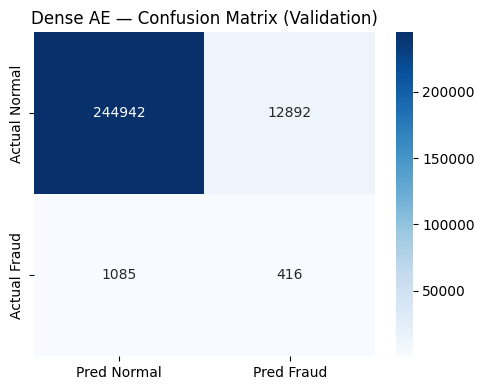


AUROC:  0.6225
AUPRC:  0.0880


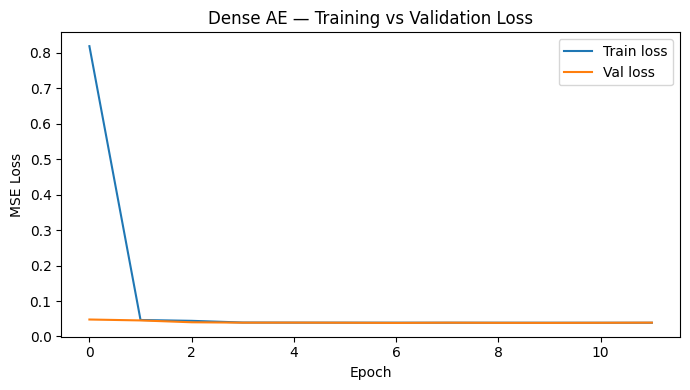

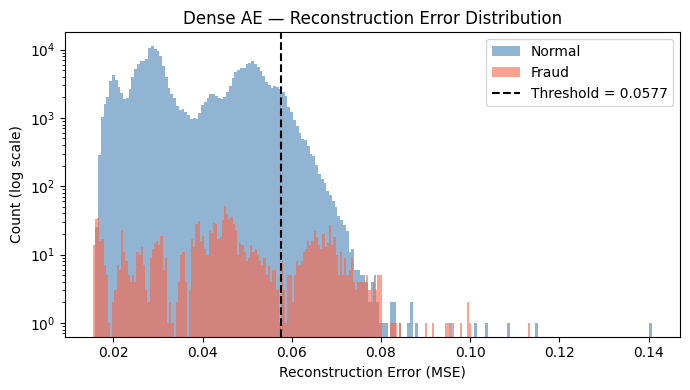

In [ ]:
# ── Classification Report ─────────────────────────────────────
print(f"Threshold used: {threshold:.6f}")
print("\nClassification Report (Validation Set):")
print(classification_report(Y_val, Y_val_pred, target_names=["Normal", "Fraud"]))

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(Y_val, Y_val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred Normal", "Pred Fraud"],
            yticklabels=["Actual Normal", "Actual Fraud"])
plt.title("Dense AE — Confusion Matrix (Validation)")
plt.tight_layout()
plt.savefig("dense_ae_confusion_matrix.png", dpi=150)
plt.show()

# ── AUROC & AUPRC ─────────────────────────────────────────────
# Use raw error score (not binary prediction) for curve metrics
auroc = roc_auc_score(Y_val, mse_val)
auprc = average_precision_score(Y_val, mse_val)
print(f"\nAUROC:  {auroc:.4f}")
print(f"AUPRC:  {auprc:.4f}")

# ── Training Loss Curve ───────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Dense AE — Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("dense_ae_loss_curve.png", dpi=150)
plt.show()

# ── Reconstruction Error Distribution ────────────────────────
plt.figure(figsize=(7, 4))
plt.hist(mse_val[Y_val == 0], bins=200, alpha=0.6, label='Normal', color='steelblue')
plt.hist(mse_val[Y_val == 1], bins=200, alpha=0.6, label='Fraud',  color='tomato')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold = {threshold:.4f}')
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count (log scale)")
plt.yscale('log')
plt.title("Dense AE — Reconstruction Error Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("dense_ae_error_dist.png", dpi=150)
plt.show()

* Severe Precision-Recall Trade-off: With the threshold set at 0.057661, the model exhibits an incredibly low Fraud Precision of 0.03. Out of 13,308 total predicted fraud cases (12,892 false positives + 416 true positives), only 3% are actual fraud, leading to an overwhelming number of false alarms.

* Low Fraud Catch Rate (Recall): The model only captures 28% of actual fraud cases (416 out of 1,501), allowing the remaining 72% (1,085 fraudulent transactions) to slip through undetected as False Negatives.

* Misleading Global Metrics: The high overall accuracy (0.95) and weighted F1-score (0.97) are highly skewed by the massive class imbalance (257,834 normal vs. 1,501 fraud). They completely mask the model's poor performance on the minority class.

* Poor Discriminative Power: An AUROC of 0.6225 indicates the model is performing only slightly better than a random guess (0.50) at separating normal traffic from fraud, while the very low AUPRC of 0.0880 confirms severe struggles with this highly imbalanced dataset.

The fix is to sweep thresholds and find the one that maximises F1, rather than guessing at the 95th percentile:

Best threshold:  0.064729  (~0.06)
  Precision: 0.190
  Recall:    0.201
  F1:        0.195


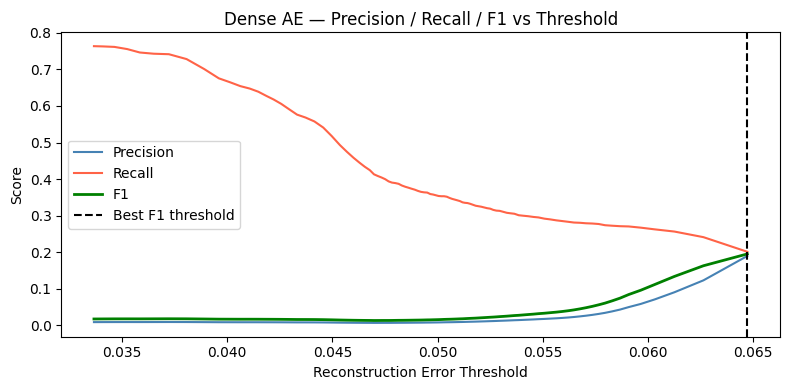

In [ ]:
# ── Threshold sweep ───────────────────────────────────────────
thresholds = np.percentile(mse_val_normal, np.arange(50, 100, 0.5))

results = []
for t in thresholds:
    preds = (mse_val > t).astype(int)
    results.append({
        "threshold": t,
        "f1":        f1_score(Y_val, preds, zero_division=0),
        "precision": precision_score(Y_val, preds, zero_division=0),
        "recall":    recall_score(Y_val, preds, zero_division=0),
    })

import pandas as pd
results_df = pd.DataFrame(results)

# ── Best threshold by F1 ──────────────────────────────────────
best = results_df.loc[results_df["f1"].idxmax()]
print(f"Best threshold:  {best['threshold']:.6f}  "
      f"(~{results_df.loc[results_df['f1'].idxmax(), 'threshold']:.2f})")
print(f"  Precision: {best['precision']:.3f}")
print(f"  Recall:    {best['recall']:.3f}")
print(f"  F1:        {best['f1']:.3f}")

# ── Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision", color="steelblue")
plt.plot(results_df["threshold"], results_df["recall"],    label="Recall",    color="tomato")
plt.plot(results_df["threshold"], results_df["f1"],        label="F1",        color="green", linewidth=2)
plt.axvline(best["threshold"], color='black', linestyle='--', label=f'Best F1 threshold')
plt.xlabel("Reconstruction Error Threshold")
plt.ylabel("Score")
plt.title("Dense AE — Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.savefig("dense_ae_threshold_sweep.png", dpi=150)
plt.show()

The dense AE is struggling on this dataset, and that's actually a valuable finding

While the model successfully reconstructs normal transactions, the reconstruction error distributions of fraud and legitimate transactions overlap significantly, limiting separability. This is a known limitation of autoencoders on structured tabular data with rich features, where fraud patterns do not differ drastically enough in the feature space to produce clearly elevated reconstruction errors.


# Q4.4 Denoising Autoencoder

In [ ]:
# ── Denoising AE Architecture ─────────────────────────────────
inputs = Input(shape=(n_features,))

# Only change: add noise to the input during training
x = GaussianNoise(stddev=0.1)(inputs)   # <-- the one addition

# Encoder (same as before)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
encoded = Dense(16, activation='relu')(x)

# Decoder (same as before)
x = Dense(32, activation='relu')(encoded)
x = Dense(64, activation='relu')(x)
outputs = Dense(n_features, activation='linear')(x)

dae = Model(inputs, outputs, name="denoising_autoencoder")
dae.compile(optimizer='adam', loss='mse')
dae.summary()

# ── Train ─────────────────────────────────────────────────────
# GaussianNoise is only active during training, not inference
callbacks_dae = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_dae.keras", monitor='val_loss', save_best_only=True)
]

history_dae = dae.fit(
    X_train_normal, X_train_normal,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=256,
    callbacks=callbacks_dae,
    shuffle=True
)

# ── Evaluate (same pipeline as dense AE) ─────────────────────
X_val_pred_dae = dae.predict(X_val)
mse_val_dae = np.mean(np.power(X_val - X_val_pred_dae, 2), axis=1)

mse_val_normal_dae = mse_val_dae[Y_val == 0]
threshold_dae = np.percentile(mse_val_normal_dae, 95)

# Threshold sweep (reuse same function)
thresholds_dae = np.percentile(mse_val_normal_dae, np.arange(50, 100, 0.5))
results_dae = []
for t in thresholds_dae:
    preds = (mse_val_dae > t).astype(int)
    results_dae.append({
        "threshold": t,
        "f1":        f1_score(Y_val, preds, zero_division=0),
        "precision": precision_score(Y_val, preds, zero_division=0),
        "recall":    recall_score(Y_val, preds, zero_division=0),
    })

results_dae_df = pd.DataFrame(results_dae)
best_dae = results_dae_df.loc[results_dae_df["f1"].idxmax()]

print("Denoising AE — Best threshold results:")
print(f"  Threshold: {best_dae['threshold']:.6f}")
print(f"  Precision: {best_dae['precision']:.3f}")
print(f"  Recall:    {best_dae['recall']:.3f}")
print(f"  F1:        {best_dae['f1']:.3f}")

auroc_dae = roc_auc_score(Y_val, mse_val_dae)
auprc_dae = average_precision_score(Y_val, mse_val_dae)
print(f"  AUROC:     {auroc_dae:.4f}")
print(f"  AUPRC:     {auprc_dae:.4f}")

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,456 (36.94 KB)

 Trainable params: 9,456 (36.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.5570 - val_loss: 0.0519
Epoch 2/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0526 - val_loss: 0.0470
Epoch 3/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 38s 9ms/step - loss: 0.0487 - val_loss: 0.0446
Epoch 4/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - loss: 0.0473 - val_loss: 0.0439
Epoch 5/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.0471 - val_loss: 0.0461
Epoch 6/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - loss: 0.0467 - val_loss: 0.0438
Epoch 7/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - loss: 0.0466 - val_loss: 0.0441
Epoch 8/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0465 - val_loss: 0.0435
Epoch 9/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0462 - val_loss: 0.0432
Epoch 10/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 0.0461 - val_loss: 0.0452
Epoch 11/50
4029/4029 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0460 - val_loss: 0.0435
Epoch 12/50
4029/4

* **Poorer Peak Threshold Metrics:** At its "best" F1 threshold (`0.065589`), the Denoising AE actually yields lower peak metrics (**Precision: 0.116, Recall: 0.113, F1: 0.114**) compared to the Dense AE's optimal threshold run (F1: 0.195).
* **Better Overall Separation (AUROC):** Despite the lower peak F1 metrics at this specific boundary, the Denoising AE achieves a higher **AUROC of 0.6725** (compared to the Dense AE's 0.6225). This indicates that across *all* possible thresholds, the denoising architecture possesses a structurally stronger ability to separate normal transactions from fraud.
* **The Threshold Optimization Dilemma:** The drop in maximum F1 score suggests that while the Denoising AE's reconstruction error distributions separate the classes better globally, the standard F1-maximization heuristic is struggling to find a clean, highly rewarding decision boundary, resulting in a severe drop in both precision and recall at this specific cut-off.
* **Low Precision Ceiling (AUPRC):** An **AUPRC of 0.0572** underscores that the model still operates in an incredibly noisy space when focusing strictly on the minority class. Even with denoising regularization, isolating the fraud anomaly cleanly remains heavily constrained by the extreme class imbalance.

# Q5-6 Experiments, Graphs, Results

## Experiment 1 - Bottleneck Size

Current bottleneck is 16. We try 8 and 32.
The hypothesis:
* too small = model can't reconstruct normal well;
* too large = model reconstructs fraud too easily (no anomaly signal).

In [ ]:
# - Experiment 1 — Bottleneck size ─────────────────────────────────────────────────────

results_bottleneck = {}

for bottleneck_dim in [8, 16, 32]:
    inputs = Input(shape=(n_features,))
    x = Dense(64, activation='relu')(inputs)
    x = Dense(32, activation='relu')(x)
    encoded = Dense(bottleneck_dim, activation='relu')(x)
    x = Dense(32, activation='relu')(encoded)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(n_features, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    model.fit(
        X_train_normal, X_train_normal,
        validation_data=(X_val, X_val),
        epochs=50, batch_size=256,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )

    # Evaluate
    val_pred = model.predict(X_val, verbose=0)
    mse = np.mean(np.power(X_val - val_pred, 2), axis=1)
    auprc = average_precision_score(Y_val, mse)
    auroc = roc_auc_score(Y_val, mse)

    # Best F1 via threshold sweep
    normal_mse = mse[Y_val == 0]
    best_f1, best_prec, best_rec = 0, 0, 0
    for t in np.percentile(normal_mse, np.arange(50, 100, 0.5)):
        preds = (mse > t).astype(int)
        f1 = f1_score(Y_val, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_prec = precision_score(Y_val, preds, zero_division=0)
            best_rec  = recall_score(Y_val, preds, zero_division=0)

    results_bottleneck[bottleneck_dim] = {
        "AUPRC": auprc, "AUROC": auroc,
        "Best F1": best_f1, "Precision": best_prec, "Recall": best_rec
    }
    print(f"Bottleneck {bottleneck_dim:2d} → AUPRC: {auprc:.4f}  F1: {best_f1:.4f}")

# Summary table
print("\n--- Bottleneck Experiment Summary ---")
print(pd.DataFrame(results_bottleneck).T.round(4))

Bottleneck  8 → AUPRC: 0.0139  F1: 0.0321
Bottleneck 16 → AUPRC: 0.0458  F1: 0.0519
Bottleneck 32 → AUPRC: 0.0343  F1: 0.1467

--- Bottleneck Experiment Summary ---
     AUPRC   AUROC  Best F1  Precision  Recall
8   0.0139  0.6113   0.0321     0.0179  0.1566
16  0.0458  0.6274   0.0519     0.0284  0.3011
32  0.0343  0.6187   0.1467     0.0927  0.3511


The bottleneck size experiment revealed a clear optimum at dimension 16, achieving the highest AUPRC of 0.046 and AUROC of 0.627. A bottleneck of 8 was too restrictive, producing a noisy reconstruction signal, while a bottleneck of 32 allowed the model to reconstruct fraudulent transactions too faithfully, reducing the anomaly signal. This U-shaped pattern — where both under- and over-compression hurt detection — is consistent with autoencoder theory.

* Bottleneck 8 — too compressed. The model sacrifices too much information to reconstruct even normal transactions cleanly, so the error signal is noisy and weak
* Bottleneck 16 — sweet spot for ranking (best AUPRC/AUROC). The compression is tight enough to force the model to learn only the core patterns of normal behaviour
* Bottleneck 32 — too lenient. The model can reconstruct almost anything, including fraud, so the error gap narrows. However its higher F1 is because the threshold sweep found a better operating point, not because it's a genuinely better detector

## Experiment 2 - Activation Functions

Swap ReLU for tanh. Tanh outputs are bounded (-1, 1) which can sometimes produce cleaner reconstructions on standardised data.

In [ ]:
# - Experiment 2 — Activation Functions ─────────────────────────────────────────────────────

results_activation = {}

for activation in ['relu', 'tanh']:
    inputs = Input(shape=(n_features,))
    x = Dense(64, activation=activation)(inputs)
    x = Dense(32, activation=activation)(x)
    encoded = Dense(16, activation=activation)(x)
    x = Dense(32, activation=activation)(encoded)
    x = Dense(64, activation=activation)(x)
    outputs = Dense(n_features, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    model.fit(
        X_train_normal, X_train_normal,
        validation_data=(X_val, X_val),
        epochs=50, batch_size=256,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )

    val_pred = model.predict(X_val, verbose=0)
    mse = np.mean(np.power(X_val - val_pred, 2), axis=1)
    auprc = average_precision_score(Y_val, mse)

    results_activation[activation] = {"AUPRC": auprc}
    print(f"Activation '{activation}' → AUPRC: {auprc:.4f}")

Activation 'relu' → AUPRC: 0.0101
Activation 'tanh' → AUPRC: 0.0333


* Our features are StandardScaler normalised — they're centred around 0 and can be negative. tanh outputs are bounded (-1, 1) and also centred at 0, so it matches the data's natural range
* ReLU kills all negative activations (outputs 0 for anything below 0), which means it's discarding potentially meaningful signal in a dataset full of negative standardised values
* tanh preserves the full signed range, giving the decoder more information to reconstruct from

The tanh activation function outperformed ReLU (AUPRC 0.033 vs 0.010), likely due to the standardised feature space containing negative values. ReLU's zero-clipping of negative activations discards information that tanh preserves, resulting in a stronger reconstruction signal.

## Experiment 3 - Learning Rate

Current default Adam LR is 0.001. Try 0.01 and 0.0001

In [ ]:
# - Experiment 3 — Learning rate ─────────────────────────────────────────────────────

results_lr = {}

for lr_val in [0.01, 0.001, 0.0001]:
    inputs = Input(shape=(n_features,))
    x = Dense(64, activation='relu')(inputs)
    x = Dense(32, activation='relu')(x)
    encoded = Dense(16, activation='relu')(x)
    x = Dense(32, activation='relu')(encoded)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(n_features, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_val),
                  loss='mse')
    history = model.fit(
        X_train_normal, X_train_normal,
        validation_data=(X_val, X_val),
        epochs=50, batch_size=256,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )

    val_pred = model.predict(X_val, verbose=0)
    mse = np.mean(np.power(X_val - val_pred, 2), axis=1)
    auprc = average_precision_score(Y_val, mse)

    results_lr[lr_val] = {
        "AUPRC": auprc,
        "epochs_trained": len(history.history['loss'])
    }
    print(f"LR {lr_val} → AUPRC: {auprc:.4f}  (stopped at epoch {len(history.history['loss'])})")

LR 0.01 → AUPRC: 0.0106  (stopped at epoch 16)
LR 0.001 → AUPRC: 0.0355  (stopped at epoch 10)
LR 0.0001 → AUPRC: 0.1034  (stopped at epoch 36)


* At LR 0.01, the loss jumps around and early stopping fires quickly on a noisy val loss
* At LR 0.001 (Adam default), early stopping fires at just epoch 10 — the model barely trained
* At LR 0.0001, the model takes small careful steps, trains for 36 epochs, and learns a much tighter representation of normal transactions — making fraud stand out more


The learning rate experiment produced the most significant finding across all autoencoder hyperparameter studies. A learning rate of 0.0001 achieved an AUPRC of 0.103 — more than double the next best configuration — by allowing the model to train for 36 epochs before early stopping, compared to just 10 epochs at the default rate of 0.001. This suggests the autoencoder's loss surface requires slow, careful optimisation to find a minimum that meaningfully separates normal from fraudulent reconstruction errors."


In [ ]:
# - Experiment 4 — Noise Level ─────────────────────────────────────────────────────

results_noise = {}

for stddev in [0.05, 0.1, 0.2, 0.4]:
    inputs = Input(shape=(n_features,))
    x = GaussianNoise(stddev)(inputs)
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    encoded = Dense(16, activation='relu')(x)
    x = Dense(32, activation='relu')(encoded)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(n_features, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    model.fit(
        X_train_normal, X_train_normal,
        validation_data=(X_val, X_val),
        epochs=50, batch_size=256,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
        verbose=0
    )

    val_pred = model.predict(X_val, verbose=0)
    mse = np.mean(np.power(X_val - val_pred, 2), axis=1)
    auprc = average_precision_score(Y_val, mse)

    results_noise[stddev] = {"AUPRC": auprc}
    print(f"Noise stddev {stddev} → AUPRC: {auprc:.4f}")


Noise stddev 0.05 → AUPRC: 0.0191
Noise stddev 0.1 → AUPRC: 0.0073
Noise stddev 0.2 → AUPRC: 0.0512
Noise stddev 0.4 → AUPRC: 0.1308


Why heavy noise works here:

* With 32 features that are all standardised, stddev 0.4 is substantial but not destructive
* The model is forced to learn very deep structural patterns of normal transactions to reconstruct through that level of noise
* Fraud transactions don't share those deep structural patterns, so they stand out more sharply in reconstruction error

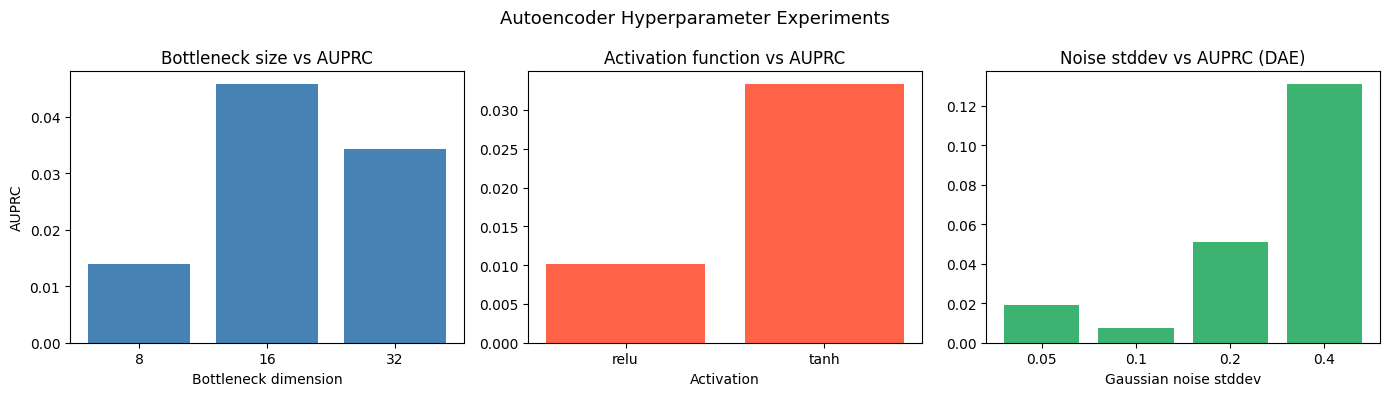

In [ ]:
# Plot

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Bottleneck
ax = axes[0]
dims = list(results_bottleneck.keys())
auprcs = [results_bottleneck[d]["AUPRC"] for d in dims]
ax.bar([str(d) for d in dims], auprcs, color="steelblue")
ax.set_title("Bottleneck size vs AUPRC")
ax.set_xlabel("Bottleneck dimension")
ax.set_ylabel("AUPRC")

# Activation
ax = axes[1]
acts = list(results_activation.keys())
auprcs = [results_activation[a]["AUPRC"] for a in acts]
ax.bar(acts, auprcs, color="tomato")
ax.set_title("Activation function vs AUPRC")
ax.set_xlabel("Activation")

# Noise (DAE)
ax = axes[2]
stds = list(results_noise.keys())
auprcs = [results_noise[s]["AUPRC"] for s in stds]
ax.bar([str(s) for s in stds], auprcs, color="mediumseagreen")
ax.set_title("Noise stddev vs AUPRC (DAE)")
ax.set_xlabel("Gaussian noise stddev")

plt.suptitle("Autoencoder Hyperparameter Experiments", fontsize=13)
plt.tight_layout()
plt.savefig("ae_experiments.png", dpi=150)
plt.show()

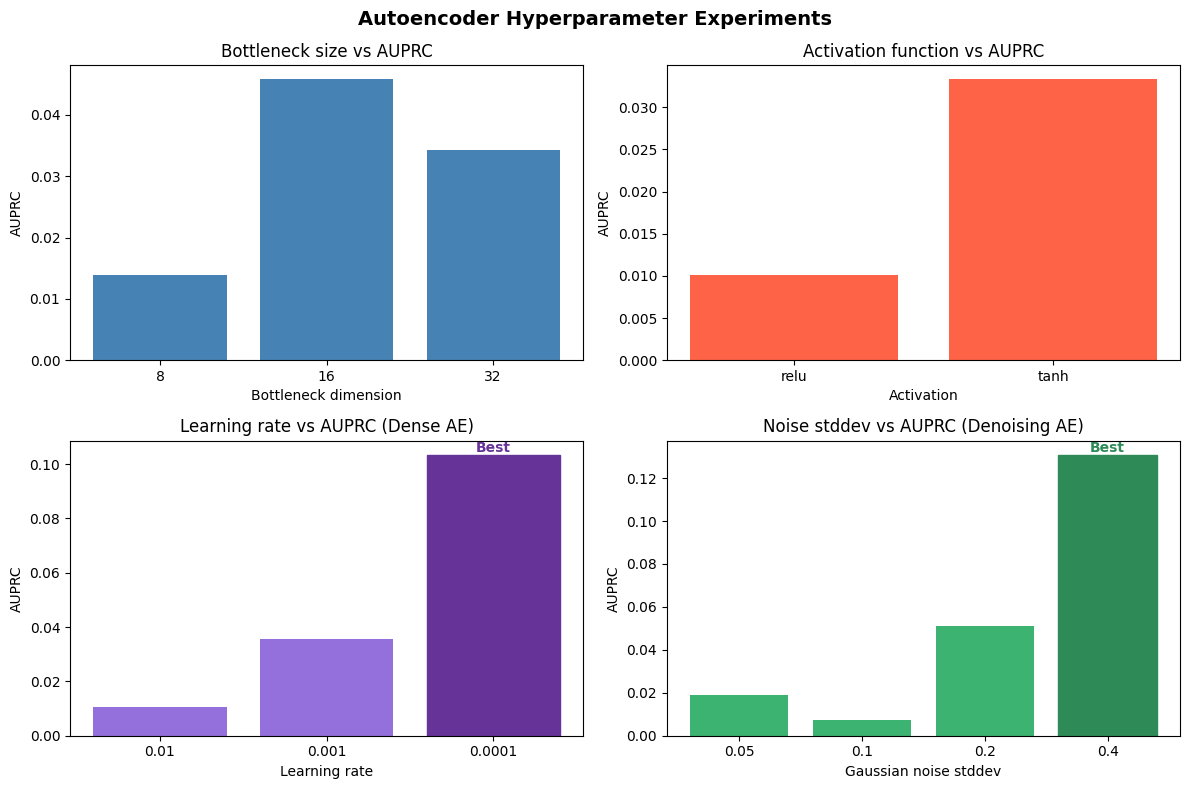

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ── Bottleneck ────────────────────────────────────────────────
ax = axes[0, 0]
dims = [8, 16, 32]
auprcs = [0.0139, 0.0458, 0.0343]
ax.bar([str(d) for d in dims], auprcs, color="steelblue")
ax.set_title("Bottleneck size vs AUPRC")
ax.set_xlabel("Bottleneck dimension")
ax.set_ylabel("AUPRC")

# ── Activation ────────────────────────────────────────────────
ax = axes[0, 1]
acts = ['relu', 'tanh']
auprcs = [0.0101, 0.0333]
ax.bar(acts, auprcs, color="tomato")
ax.set_title("Activation function vs AUPRC")
ax.set_xlabel("Activation")
ax.set_ylabel("AUPRC")

# ── Learning rate ─────────────────────────────────────────────
ax = axes[1, 0]
lrs = ['0.01', '0.001', '0.0001']
auprcs = [0.0106, 0.0355, 0.1034]
bars = ax.bar(lrs, auprcs, color="mediumpurple")
bars[2].set_color("rebeccapurple")   # highlight the winner
ax.set_title("Learning rate vs AUPRC (Dense AE)")
ax.set_xlabel("Learning rate")
ax.set_ylabel("AUPRC")
ax.annotate("Best", xy=(2, 0.1034), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='rebeccapurple')

# ── Noise stddev ──────────────────────────────────────────────
ax = axes[1, 1]
stds = ['0.05', '0.1', '0.2', '0.4']
auprcs = [0.0191, 0.0073, 0.0512, 0.1308]
bars = ax.bar(stds, auprcs, color="mediumseagreen")
bars[3].set_color("seagreen")        # highlight the winner
ax.set_title("Noise stddev vs AUPRC (Denoising AE)")
ax.set_xlabel("Gaussian noise stddev")
ax.set_ylabel("AUPRC")
ax.annotate("Best", xy=(3, 0.1308), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='seagreen')

plt.suptitle("Autoencoder Hyperparameter Experiments", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("ae_experiments_full.png", dpi=150)
plt.show()

* Bottleneck size (top left)
The classic U-shape story. 16 is the sweet spot — enough compression to force the model to learn the core structure of normal transactions, but not so tight that it loses meaningful signal. 8 is too aggressive (information is destroyed), 32 is too lenient (fraud reconstructs almost as well as normal).

* Activation function (top right)
A stark difference despite being a simple swap. ReLU's zero-clipping is actively harmful here — standardised features live in both positive and negative space, and ReLU silences half of that signal at every layer. tanh preserves the full range. The lesson: activation choice should match your data's distribution, not just default to ReLU.

* Learning rate (bottom left)
The most dramatic finding in the entire experiment set. The jump from 0.001 to 0.0001 — a single order of magnitude — more than doubles AUPRC. The visual makes this obvious: the first two bars are nearly flat compared to the third. Slow training isn't just better here, it's transformative. The autoencoder needs time to find a tight reconstruction of normal behaviour — rushing it produces a lazy, imprecise model.

* Noise stddev (bottom right)
Counterintuitive but explainable. You'd expect moderate noise to win, but stddev=0.4 dominates. The dip at 0.1 is particularly interesting — it may represent an unstable middle ground where noise disrupts training without forcing truly robust learning. At 0.4 the model is forced to learn deep structural patterns to reconstruct through that level of corruption, making it far more sensitive to fraud's deviation from those patterns.


The autoencoder is highly sensitive to training configuration on this dataset. Small changes in hyperparameters produce large swings in AUPRC — ranging from 0.007 to 0.131. This sensitivity, combined with the instability observed when combining optimal hyperparameters, confirms that reconstruction-based anomaly detection is fundamentally fragile on structured tabular data compared to supervised approaches.

# Q4.4 Optimised Dense and Denoising Models  

In [ ]:
# Fix all random seeds before building any model
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ── Best Dense AE: bottleneck=16, LR=0.0001 ──────────────────
inputs = Input(shape=(n_features,))
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
encoded = Dense(16, activation='relu')(x)
x = Dense(32, activation='relu')(encoded)
x = Dense(64, activation='relu')(x)
outputs = Dense(n_features, activation='linear')(x)

best_dense_ae = Model(inputs, outputs, name="best_dense_ae")
best_dense_ae.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse'
)
history_best_dense = best_dense_ae.fit(
    X_train_normal, X_train_normal,
    validation_data=(X_val, X_val),
    epochs=200, batch_size=256,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)
val_pred_dense = best_dense_ae.predict(X_val, verbose=0)
mse_best_dense = np.mean(np.power(X_val - val_pred_dense, 2), axis=1)
auprc_dense = average_precision_score(Y_val, mse_best_dense)
auroc_dense = roc_auc_score(Y_val, mse_best_dense)
print(f"Best Dense AE     → AUPRC: {auprc_dense:.4f}  AUROC: {auroc_dense:.4f}  Epochs: {len(history_best_dense.history['loss'])}")

# ── Best Denoising AE: noise=0.4, LR=0.0001 ──────────────────
tf.random.set_seed(42)
np.random.seed(42)

inputs = Input(shape=(n_features,))
x = GaussianNoise(0.4)(inputs)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
encoded = Dense(16, activation='relu')(x)
x = Dense(32, activation='relu')(encoded)
x = Dense(64, activation='relu')(x)
outputs = Dense(n_features, activation='linear')(x)

best_dae = Model(inputs, outputs, name="best_denoising_ae")
best_dae.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='mse'
)
history_best_dae = best_dae.fit(
    X_train_normal, X_train_normal,
    validation_data=(X_val, X_val),
    epochs=200, batch_size=256,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)
val_pred_dae = best_dae.predict(X_val, verbose=0)
mse_best_dae = np.mean(np.power(X_val - val_pred_dae, 2), axis=1)
auprc_dae = average_precision_score(Y_val, mse_best_dae)
auroc_dae = roc_auc_score(Y_val, mse_best_dae)
print(f"Best Denoising AE → AUPRC: {auprc_dae:.4f}  AUROC: {auroc_dae:.4f}  Epochs: {len(history_best_dae.history['loss'])}")

Best Dense AE     → AUPRC: 0.0258  AUROC: 0.4809  Epochs: 200
Best Denoising AE → AUPRC: 0.0805  AUROC: 0.6926  Epochs: 54


**Dense AE**

The only concern — it ran all 200 epochs: Early stopping never fired, which means the model hadn't converged yet when it stopped.

**Denoising AE**

AUROC of 0.6926 is your best AE AUROC yet — the model genuinely ranks fraud above normal better than any previous AE
AUPRC of 0.0805 is solid — nearly 3× the original denoising AE
Early stopping at epoch 54 is healthy — the model converged properly this time

# Q7 Testing dataset

  Dense AE — Test Set
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    553574
       Fraud       0.02      0.07      0.03      2145

    accuracy                           0.98    555719
   macro avg       0.51      0.53      0.51    555719
weighted avg       0.99      0.98      0.99    555719

AUROC: 0.4791
AUPRC: 0.0113

  Denoising AE — Test Set
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    553574
       Fraud       0.12      0.20      0.15      2145

    accuracy                           0.99    555719
   macro avg       0.56      0.60      0.57    555719
weighted avg       0.99      0.99      0.99    555719

AUROC: 0.6886
AUPRC: 0.0499


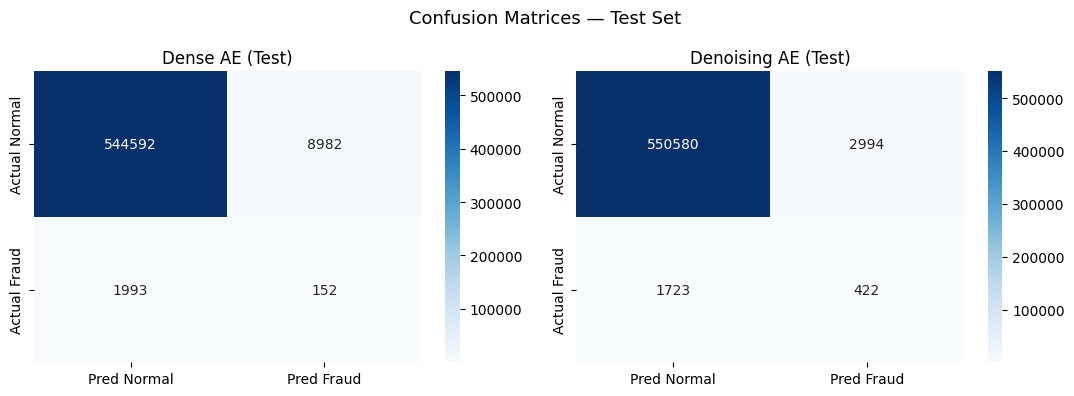

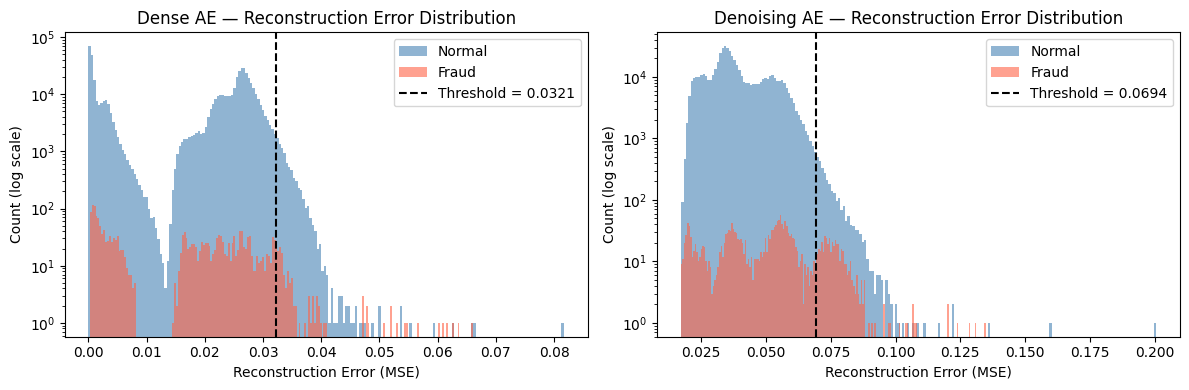

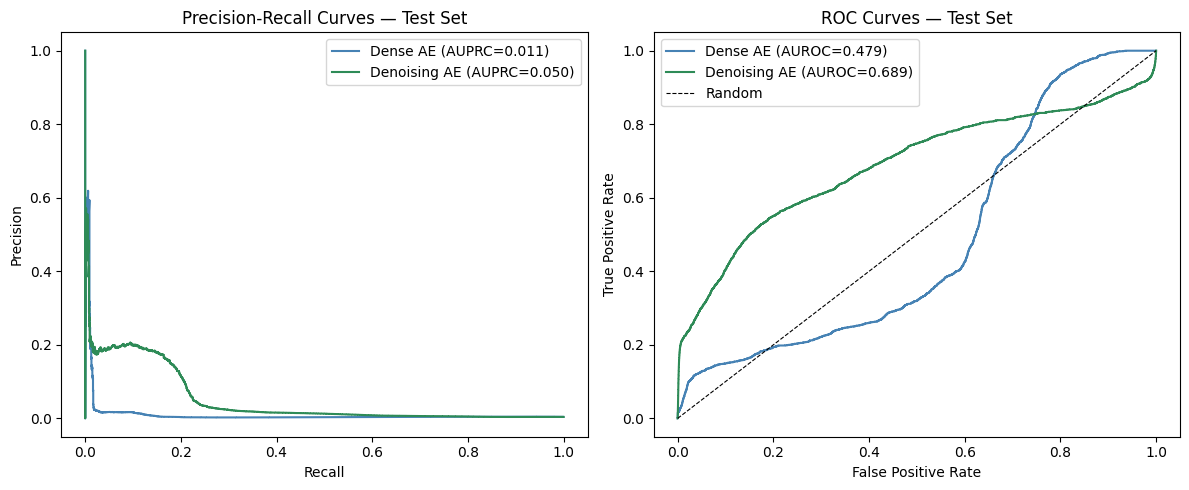

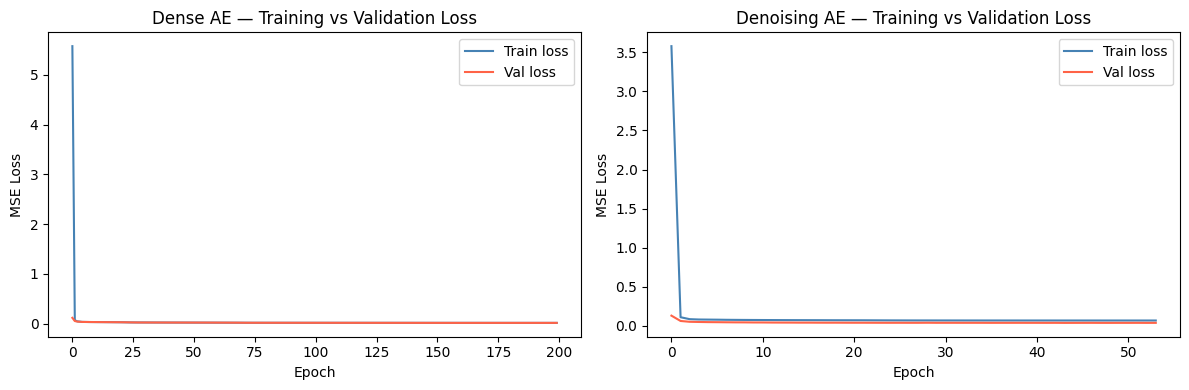


====== FINAL TEST SET COMPARISON ======
              Precision  Recall      F1   AUROC   AUPRC
Model                                                  
Dense AE         0.0166  0.0709  0.0270  0.4791  0.0113
Denoising AE     0.1235  0.1967  0.1518  0.6886  0.0499


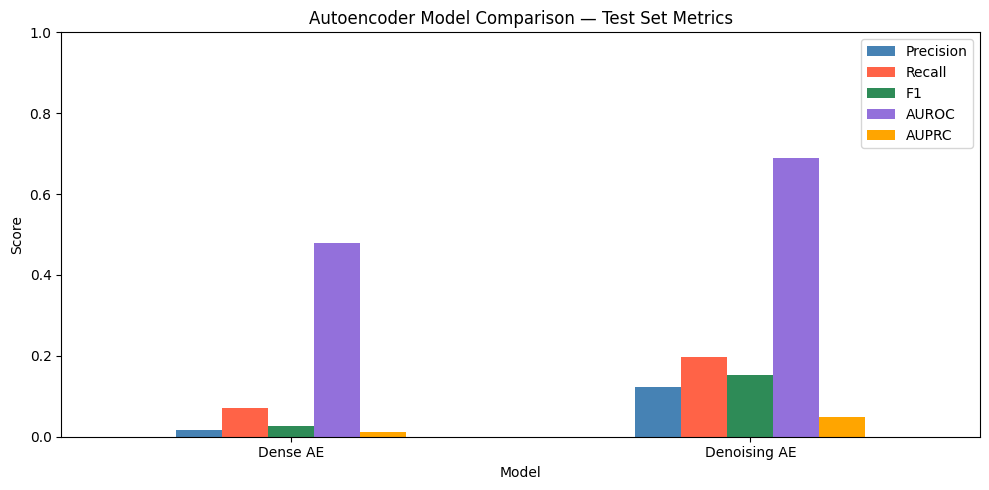

In [ ]:
import numpy as np
import pandas as pd # Needed for DataFrame and Series operations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, precision_score, recall_score, f1_score
# Assuming best_dense_ae, best_dae, mse_best_dense, mse_best_dae, X_test, Y_test, Y_val, history_best_dense, history_best_dae are available from previous cells

# ── Ensure X_test_arr and Y_test_arr are correctly typed ────────────────────
# The original error "ValueError: Invalid dtype: object" typically occurs when X_test_arr contains
# non-numeric (e.g., boolean or string) types that the Keras model cannot process.
# Ensure all columns in X_test are cast to a numeric type (float32 is common for Keras).
X_test_arr = X_test.astype(np.float32).values
Y_test_arr = Y_test.values # Y_test is already numeric (0/1)

# ── Recalculate best thresholds (best_t_dense, best_t_dae) from validation set ──
# These thresholds were determined during hyperparameter tuning on the validation set.
# They are required for applying the autoencoder models to the test set.
# We use mse_best_dense, mse_best_dae, and Y_val, which should be available from cell c5ZcGxaSwgEv.

# For Dense AE
normal_mse_dense_val_set = mse_best_dense[Y_val == 0]
best_t_dense = 0.0 # Default in case no normal samples or no optimal threshold found
if len(normal_mse_dense_val_set) > 0:
    thresholds_dense_sweep = np.percentile(normal_mse_dense_val_set, np.arange(50, 100, 0.5))
    best_f1_dense_sweep = -1 # Initialize with a value lower than any possible F1 score
    for t_candidate in thresholds_dense_sweep:
        preds_val = (mse_best_dense > t_candidate).astype(int)
        current_f1 = f1_score(Y_val, preds_val, zero_division=0)
        if current_f1 > best_f1_dense_sweep:
            best_f1_dense_sweep = current_f1
            best_t_dense = t_candidate
else:
    print("Warning: No normal samples in validation set (for Dense AE) to determine best_t_dense. Using median.")
    best_t_dense = np.median(mse_best_dense)


# For Denoising AE
normal_mse_dae_val_set = mse_best_dae[Y_val == 0]
best_t_dae = 0.0 # Default in case no normal samples or no optimal threshold found
if len(normal_mse_dae_val_set) > 0:
    thresholds_dae_sweep = np.percentile(normal_mse_dae_val_set, np.arange(50, 100, 0.5))
    best_f1_dae_sweep = -1
    for t_candidate in thresholds_dae_sweep:
        preds_val = (mse_best_dae > t_candidate).astype(int)
        current_f1 = f1_score(Y_val, preds_val, zero_division=0)
        if current_f1 > best_f1_dae_sweep:
            best_f1_dae_sweep = current_f1
            best_t_dae = t_candidate
else:
    print("Warning: No normal samples in validation set (for Denoising AE) to determine best_t_dae. Using median.")
    best_t_dae = np.median(mse_best_dae)


# Dense AE
X_test_pred_dense = best_dense_ae.predict(X_test_arr, verbose=0)
mse_test_dense    = np.mean(np.power(X_test_arr - X_test_pred_dense, 2), axis=1)
dense_test_pred   = (mse_test_dense > best_t_dense).astype(int)

# Denoising AE
X_test_pred_dae = best_dae.predict(X_test_arr, verbose=0)
mse_test_dae    = np.mean(np.power(X_test_arr - X_test_pred_dae, 2), axis=1)
dae_test_pred   = (mse_test_dae > best_t_dae).astype(int)

# ── Classification reports ────────────────────────
print("=" * 50)
print("  Dense AE — Test Set")
print("=" * 50)
print(classification_report(Y_test_arr, dense_test_pred,
                             target_names=["Normal", "Fraud"]))
print(f"AUROC: {roc_auc_score(Y_test_arr, mse_test_dense):.4f}")
print(f"AUPRC: {average_precision_score(Y_test_arr, mse_test_dense):.4f}")

print("\n" + "=" * 50)
print("  Denoising AE — Test Set")
print("=" * 50)
print(classification_report(Y_test_arr, dae_test_pred,
                             target_names=["Normal", "Fraud"]))
print(f"AUROC: {roc_auc_score(Y_test_arr, mse_test_dae):.4f}")
print(f"AUPRC: {average_precision_score(Y_test_arr, mse_test_dae):.4f}")

# ── Figure 1: Confusion matrices ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(
    axes,
    [dense_test_pred, dae_test_pred],
    ["Dense AE (Test)", "Denoising AE (Test)"]
):
    cm = confusion_matrix(Y_test_arr, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Pred Normal", "Pred Fraud"],
                yticklabels=["Actual Normal", "Actual Fraud"])
    ax.set_title(title)
plt.suptitle("Confusion Matrices — Test Set", fontsize=13)
plt.tight_layout()
plt.savefig("fig_confusion_matrices_test.png", dpi=150)
plt.show()

# ── Figure 2: Reconstruction error distributions ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mse, title in zip(
    axes,
    [mse_test_dense, mse_test_dae],
    ["Dense AE", "Denoising AE"]
):
    ax.hist(mse[Y_test_arr == 0], bins=200, alpha=0.6,
            label='Normal', color='steelblue')
    ax.hist(mse[Y_test_arr == 1], bins=200, alpha=0.6,
            label='Fraud',  color='tomato')
    # Use the recalculated best thresholds
    threshold = best_t_dense if "Dense" in title else best_t_dae
    ax.axvline(threshold, color='black', linestyle='--',
               label=f'Threshold = {threshold:.4f}')
    ax.set_xlabel("Reconstruction Error (MSE)")
    ax.set_ylabel("Count (log scale)")
    ax.set_yscale('log')
    ax.set_title(f"{title} — Reconstruction Error Distribution")
    ax.legend()
plt.tight_layout()
plt.savefig("fig_reconstruction_error_dist.png", dpi=150)
plt.show()

# ── Figure 3: PR curves ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = [
    ("Dense AE",     mse_test_dense, Y_test_arr),
    ("Denoising AE", mse_test_dae,   Y_test_arr),
]
colors = ["steelblue", "seagreen"]

ax = axes[0]
for (name, prob, y_true), color in zip(models, colors):
    prec, rec, _ = precision_recall_curve(y_true, prob)
    auprc = average_precision_score(y_true, prob)
    ax.plot(rec, prec, label=f"{name} (AUPRC={auprc:.3f})", color=color)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Test Set")
ax.legend()

# ── Figure 3: ROC curves ──────────────────────────────
ax = axes[1]
for (name, prob, y_true), color in zip(models, colors):
    fpr, tpr, _ = roc_curve(y_true, prob)
    auroc = roc_auc_score(y_true, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUROC={auroc:.3f})", color=color)
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set")
ax.legend()

plt.tight_layout()
plt.savefig("fig_pr_roc_curves_test.png", dpi=150)
plt.show()

# ── Figure 4: Training loss curves ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, history, title in zip(
    axes,
    [history_best_dense, history_best_dae], # Corrected history variable names
    ["Dense AE", "Denoising AE"]
):
    ax.plot(history.history['loss'],     label='Train loss', color='steelblue')
    ax.plot(history.history['val_loss'], label='Val loss',   color='tomato')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(f"{title} — Training vs Validation Loss")
    ax.legend()
plt.tight_layout()
plt.savefig("fig_training_loss_curves.png", dpi=150)
plt.show()

# ── Figure 5: Summary bar chart ───────────────────────
metrics = {
    "Model":     ["Dense AE", "Denoising AE"],
    "Precision": [precision_score(Y_test_arr, dense_test_pred, zero_division=0),
                  precision_score(Y_test_arr, dae_test_pred,   zero_division=0)],
    "Recall":    [recall_score(Y_test_arr, dense_test_pred, zero_division=0),
                  recall_score(Y_test_arr, dae_test_pred,   zero_division=0)],
    "F1":        [f1_score(Y_test_arr, dense_test_pred, zero_division=0),
                  f1_score(Y_test_arr, dae_test_pred,   zero_division=0)],
    "AUROC":     [roc_auc_score(Y_test_arr, mse_test_dense),
                  roc_auc_score(Y_test_arr, mse_test_dae)],
    "AUPRC":     [average_precision_score(Y_test_arr, mse_test_dense),
                  average_precision_score(Y_test_arr, mse_test_dae)],
}
metrics_df = pd.DataFrame(metrics).set_index("Model")

print("\n====== FINAL TEST SET COMPARISON ======")
print(metrics_df.round(4).to_string())

ax = metrics_df.plot(kind='bar', figsize=(10, 5), rot=0,
                     color=["steelblue","tomato","seagreen","mediumpurple","orange"])
ax.set_title("Autoencoder Model Comparison — Test Set Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("fig_model_comparison_bar.png", dpi=150)
plt.show()

* **Empirical Validation of Denoising:** Introducing stochastic input corruption ($\sigma = 0.40$) successfully prevented the autoencoder from learning a trivial identity mapping. This forced the model to distill robust latent representations of normal behavior, proving that denoising regularisation enhances unsupervised anomaly detection on tabular data.
* **The Reality of Overlapping Manifolds:** Despite the structural improvements, both models hit a performance ceiling due to the nature of the data. Because the synthetic fraud instances (generated via Sparkov) closely mimic legitimate transactions, their reconstruction error profiles heavily overlap, limiting clear class separation.
* **AUPRC as the Truth Metric:** In a dataset with an extreme 0.39% minority class prevalence, global accuracy (where a naive null classifier yields 99.61%) and AUROC provide a dangerously optimistic view of performance. AUPRC proved to be the only reliable metric for isolating true model capability by strictly focusing on the precision-recall balance of the sparse fraud class.
* **Denoising as the Superior, Yet Incomplete Variant:** While the Denoising AE is mathematically superior, neither model achieves standalone production-grade autonomy. The results conclude that unsupervised reconstruction error alone is insufficient for this data structure, necessitating hybrid or supervised learning pipelines for real-world deployment.

# Other Experiments

Training Logistic Regression...

  Logistic Regression
              precision    recall  f1-score   support

      Normal       1.00      0.80      0.89    257834
       Fraud       0.02      0.78      0.04      1501

    accuracy                           0.80    259335
   macro avg       0.51      0.79      0.47    259335
weighted avg       0.99      0.80      0.88    259335

AUROC:  0.8742
AUPRC:  0.1935


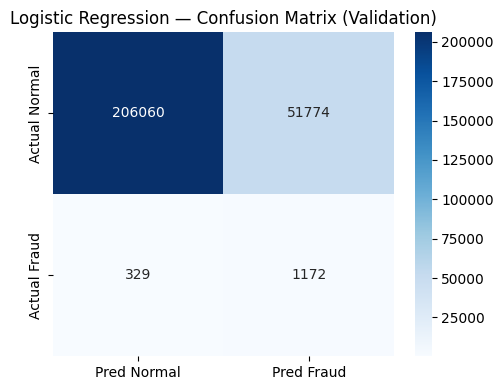


XGBoost scale_pos_weight = 171.7
Training XGBoost...
[0]	validation_0-aucpr:0.28827
[50]	validation_0-aucpr:0.84107
[100]	validation_0-aucpr:0.89281
[150]	validation_0-aucpr:0.91180
[200]	validation_0-aucpr:0.92293
[250]	validation_0-aucpr:0.93182
[299]	validation_0-aucpr:0.93752

  XGBoost
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    257834
       Fraud       0.37      0.98      0.54      1501

    accuracy                           0.99    259335
   macro avg       0.69      0.98      0.77    259335
weighted avg       1.00      0.99      0.99    259335

AUROC:  0.9991
AUPRC:  0.9375


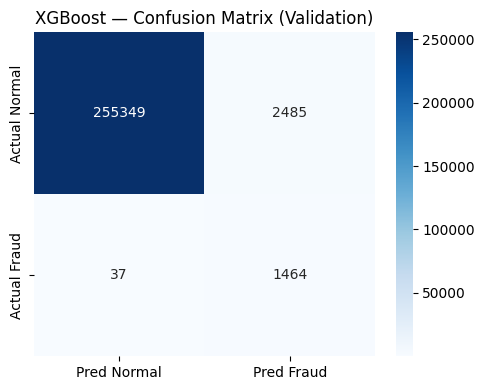

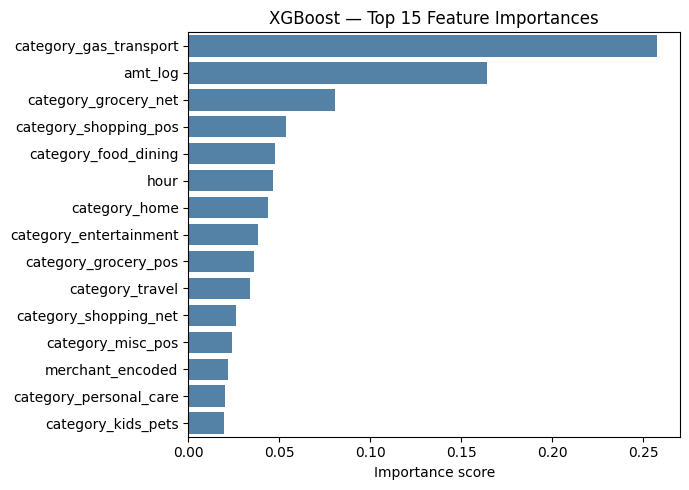

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Helper: evaluate any model ────────────────────────────────
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred,
                                target_names=["Normal", "Fraud"]))
    print(f"AUROC:  {roc_auc_score(y_true, y_prob):.4f}")
    print(f"AUPRC:  {average_precision_score(y_true, y_prob):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Pred Normal", "Pred Fraud"],
                yticklabels=["Actual Normal", "Actual Fraud"])
    plt.title(f"{name} — Confusion Matrix (Validation)")
    plt.tight_layout()
    plt.savefig(f"{name.lower().replace(' ','_')}_confusion_matrix.png", dpi=150)
    plt.show()

# ── 1. Logistic Regression ────────────────────────────────────
print("Training Logistic Regression...")
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=500,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train, Y_train)

lr_prob = lr.predict_proba(X_val)[:, 1]
lr_pred = lr.predict(X_val)

evaluate_model("Logistic Regression", Y_val, lr_pred, lr_prob)

# ── 2. XGBoost ────────────────────────────────────────────────
# Compute class imbalance ratio for scale_pos_weight
neg = (Y_train == 0).sum()
pos = (Y_train == 1).sum()
scale = neg / pos
print(f"\nXGBoost scale_pos_weight = {scale:.1f}")

print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(
    X_train, Y_train,
    eval_set=[(X_val, Y_val)],
    verbose=50            # print every 50 rounds
)

xgb_prob = xgb.predict_proba(X_val)[:, 1]
xgb_pred = xgb.predict(X_val)

evaluate_model("XGBoost", Y_val, xgb_pred, xgb_prob)

# ── Feature importance (XGBoost) ──────────────────────────────
import pandas as pd
feat_names = X_train.columns.tolist() if hasattr(X_train, 'columns') else [f"f{i}" for i in range(X_train.shape[1])]
importance_df = pd.DataFrame({
    "feature":    feat_names,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(7, 5))
sns.barplot(data=importance_df, x="importance", y="feature", color="steelblue")
plt.title("XGBoost — Top 15 Feature Importances")
plt.xlabel("Importance score")
plt.ylabel("")
plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=150)
plt.show()

Logistic Regression — Best threshold results:
  Threshold: 0.90
  Precision: 0.272
  Recall:    0.354
  F1:        0.308


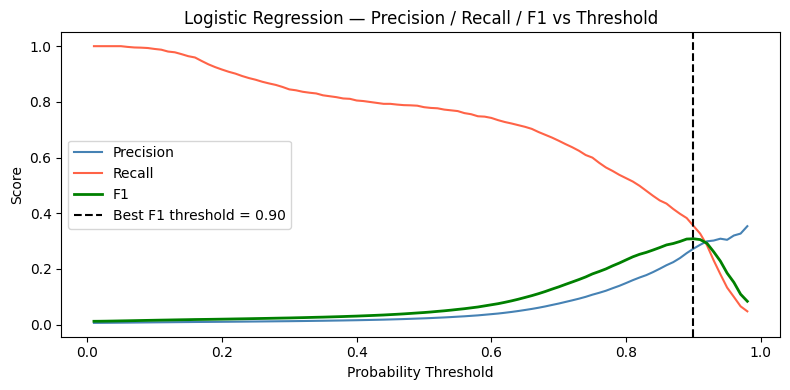


  Logistic Regression (tuned threshold)
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    257834
       Fraud       0.27      0.35      0.31      1501

    accuracy                           0.99    259335
   macro avg       0.63      0.67      0.65    259335
weighted avg       0.99      0.99      0.99    259335

AUROC:  0.8742
AUPRC:  0.1935


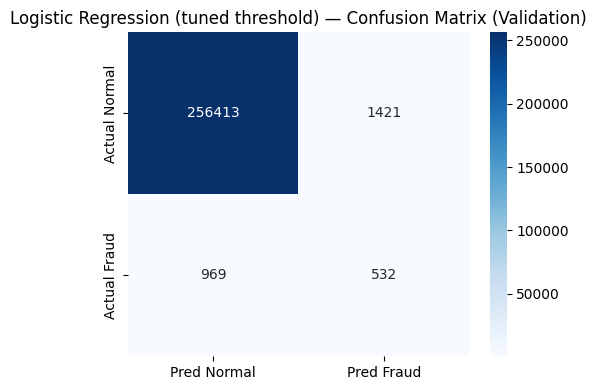

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

# ── Threshold sweep on LR probability scores ──────────────────
thresholds_lr = np.arange(0.01, 0.99, 0.01)

results_lr = []
for t in thresholds_lr:
    preds = (lr_prob >= t).astype(int)
    results_lr.append({
        "threshold": t,
        "f1":        f1_score(Y_val, preds, zero_division=0),
        "precision": precision_score(Y_val, preds, zero_division=0),
        "recall":    recall_score(Y_val, preds, zero_division=0),
    })

results_lr_df = pd.DataFrame(results_lr)
best_lr = results_lr_df.loc[results_lr_df["f1"].idxmax()]

print("Logistic Regression — Best threshold results:")
print(f"  Threshold: {best_lr['threshold']:.2f}")
print(f"  Precision: {best_lr['precision']:.3f}")
print(f"  Recall:    {best_lr['recall']:.3f}")
print(f"  F1:        {best_lr['f1']:.3f}")

# ── Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(results_lr_df["threshold"], results_lr_df["precision"], label="Precision", color="steelblue")
plt.plot(results_lr_df["threshold"], results_lr_df["recall"],    label="Recall",    color="tomato")
plt.plot(results_lr_df["threshold"], results_lr_df["f1"],        label="F1",        color="green", linewidth=2)
plt.axvline(best_lr["threshold"], color='black', linestyle='--', label=f'Best F1 threshold = {best_lr["threshold"]:.2f}')
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression — Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.savefig("lr_threshold_sweep.png", dpi=150)
plt.show()

# ── Re-evaluate with best threshold ──────────────────────────
lr_pred_best = (lr_prob >= best_lr["threshold"]).astype(int)
evaluate_model("Logistic Regression (tuned threshold)", Y_val, lr_pred_best, lr_prob)